# NLP: от текста к последовательностям
## Семинар к занятию 1

Сборная Москвы по ИИ

---

Сегодня пройдём путь от сырого текста до нейросетевых моделей:

1. **Предобработка текста** — токенизация, стемминг, лемматизация, стоп-слова
2. **Bag of Words / TF-IDF** — простейшие представления текста
3. **Word2Vec** — обучаемые эмбеддинги, дистрибутивная гипотеза
4. **Sentiment Analysis** — классификация отзывов: BoW vs Word2Vec
5. **RNN / LSTM** — генерация текста посимвольно

In [1]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F

import nltk
import gensim
from gensim.models import Word2Vec

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE

from datasets import load_dataset

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('names', quiet=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


Что мы скачали через `nltk.download(...)`:

- **punkt / punkt_tab** — предобученные модели для **токенизации**: разбиение текста на предложения и слова. Без них `sent_tokenize` / `word_tokenize` не работают.
- **stopwords** — списки стоп-слов для ~20 языков (английский, русский и др.). Используются для фильтрации частых, но бессмысленных слов.
- **wordnet** — лексическая база WordNet (>150 000 слов). Нужна лемматизатору (`WordNetLemmatizer`), чтобы знать словарные формы.
- **averaged_perceptron_tagger** — POS-теггер (Part-of-Speech): определяет часть речи каждого слова. Лемматизатор работает точнее, если знает, существительное это или глагол.
- **names** — корпус из ~8 000 английских имён (мужских и женских). Пригодится для обучения генеративной модели в конце семинара.

---
## 1. Предобработка текста (NLTK)

Прежде чем подавать текст в модель, его нужно привести в удобный формат.
Основные шаги: **токенизация** → **нормализация** (стемминг / лемматизация) → **фильтрация** (стоп-слова).

### Токенизация

Разбиение текста на предложения и слова. Кажется тривиальным, но на практике — нет: "Mr.", "don't", URL, числа...

In [3]:
from nltk.tokenize import sent_tokenize, word_tokenize

text = "Hello Mr. Adam, how are you? I hope everything is going well. Today is a good day."

print("Предложения:")
for s in sent_tokenize(text):
    print(f"  {s}")

print("\nСлова:")
print(word_tokenize(text))

Предложения:
  Hello Mr. Adam, how are you?
  I hope everything is going well.
  Today is a good day.

Слова:
['Hello', 'Mr.', 'Adam', ',', 'how', 'are', 'you', '?', 'I', 'hope', 'everything', 'is', 'going', 'well', '.', 'Today', 'is', 'a', 'good', 'day', '.']


In [4]:
text_ru = "Здравствуйте, как дела? Надеюсь, всё хорошо. Сегодня отличный день."

print("Русский текст:")
for s in sent_tokenize(text_ru, language='russian'):
    print(f"  {s}")

Русский текст:
  Здравствуйте, как дела?
  Надеюсь, всё хорошо.
  Сегодня отличный день.


### Стемминг и лемматизация

Задача: привести слова к единой форме.

- **Стемминг** — грубое обрезание окончания по правилам (Porter, Snowball). Быстро, но не всегда корректно.
- **Лемматизация** — приведение к словарной форме (лемме). Точнее, но требует знания части речи.

![stem_lemat.png](attachment:stem_lemat.png)

In [5]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

words = ["running", "ran", "runs", "better", "studies", "studying", "feet", "geese"]

print(f"{'Слово':<12} {'Стемминг':<12} {'Лемма (сущ.)':<14} {'Лемма (глаг.)':<14} {'Лемма (прил.)':<14}")
print("-" * 55)
for w in words:
    print(f"{w:<12} {stemmer.stem(w):<12} {lemmatizer.lemmatize(w, 'n'):<14} {lemmatizer.lemmatize(w, 'v'):<14} {lemmatizer.lemmatize(w, 'a'):<14}")

Слово        Стемминг     Лемма (сущ.)   Лемма (глаг.)  Лемма (прил.) 
-------------------------------------------------------
running      run          running        run            running       
ran          ran          ran            run            ran           
runs         run          run            run            runs          
better       better       better         better         good          
studies      studi        study          study          studies       
studying     studi        studying       study          studying      
feet         feet         foot           feet           feet          
geese        gees         goose          geese          geese         


Обратите внимание:
- `better` → стемминг не помогает, лемматизация тоже (нужен POS-тег `a` — прилагательное)
- `feet` → лемматизация как существительное даёт `foot`, а стемминг — `feet`
- `geese` → лемматизатор знает неправильные формы: `goose`

### Стоп-слова

**Стоп-слова** — это самые частотные слова языка, которые обычно не несут смысловой нагрузки: артикли (*the, a, an*), предлоги (*of, in, to*), местоимения (*I, he, it*), связки (*is, are, was*).

Зачем их убирать:
- В типичном тексте стоп-слова составляют **30–50%** всех токенов. Если оставить, то TF-IDF вектор будет забит бессмысленными координатами, а модель будет учиться на шуме.
- Удаление стоп-слов уменьшает размерность и ускоряет обучение.

Нюансы:
- Стоп-слова зависят от задачи. Для **sentiment analysis** слово *"not"* критически важно («not good» vs «good»), но оно входит в стандартные стоп-листы. Иногда лучше оставить отрицания.
- В `sklearn.TfidfVectorizer` можно передать `stop_words='english'` — тогда фильтрация произойдёт автоматически при построении матрицы.
- NLTK предоставляет списки стоп-слов для ~20 языков.

In [6]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

text = "The quick brown fox jumps over the lazy dog and the cat is sleeping"
tokens = word_tokenize(text.lower())
filtered = [w for w in tokens if w not in stop_words and w.isalpha()]

print(f"До:    {tokens}")
print(f"После: {filtered}")
print(f"\nУбрали {len(tokens) - len(filtered)} из {len(tokens)} токенов")

До:    ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', 'and', 'the', 'cat', 'is', 'sleeping']
После: ['quick', 'brown', 'fox', 'jumps', 'lazy', 'dog', 'cat', 'sleeping']

Убрали 6 из 14 токенов


---
## 2. Загрузка данных (IMDB)

Для следующих экспериментов нам нужен датасет. Возьмём IMDB — 50k рецензий на фильмы с бинарными метками (pos/neg).

Загружаем через HuggingFace `datasets` — это стандартный способ в 2025+ году.

In [ ]:
dataset = load_dataset('imdb')

print(f"Train: {len(dataset['train'])} текстов")
print(f"Test:  {len(dataset['test'])} текстов")
print(f"\nПример:")
print(f"  Метка: {'pos' if dataset['train'][0]['label'] == 1 else 'neg'}")
print(f"  Текст: {dataset['train'][0]['text'][:200]}...")

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

In [ ]:
train_raw = dataset['train']['text']
test_raw = dataset['test']['text']
y_train = np.array(dataset['train']['label'])
y_test = np.array(dataset['test']['label'])

print(f"Распределение меток (train): {Counter(y_train)}")
print(f"Распределение меток (test):  {Counter(y_test)}")

Распределение меток (train): Counter({np.int64(0): 12500, np.int64(1): 12500})
Распределение меток (test):  Counter({np.int64(0): 12500, np.int64(1): 12500})


Токенизируем тексты для Word2Vec (ему нужны списки слов):

In [ ]:
train_tokens = [word_tokenize(t.lower()) for t in train_raw]
test_tokens = [word_tokenize(t.lower()) for t in test_raw]

print(f"Первые 15 токенов первого отзыва: {train_tokens[0][:15]}")

Первые 15 токенов первого отзыва: ['i', 'rented', 'i', 'am', 'curious-yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that']


### Распределение длин отзывов

Прежде чем строить признаки, полезно понять, с какими текстами мы работаем. Посмотрим, сколько токенов (слов) содержит типичный отзыв. Это поможет понять:
- насколько «длинные» наши тексты (важно для выбора модели)
- есть ли выбросы (очень короткие или очень длинные отзывы)
- какой `max_features` выбирать для TF-IDF

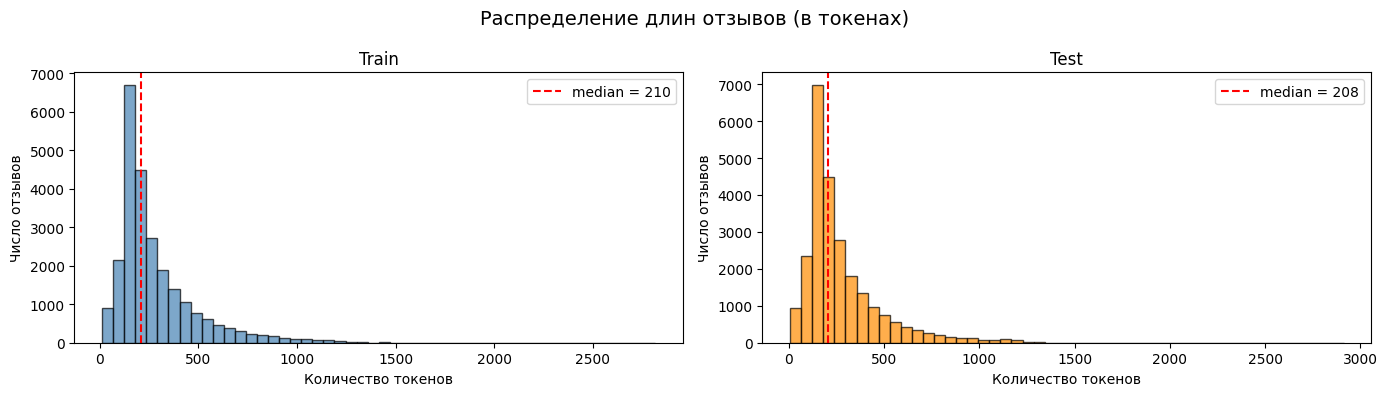

Train: min=11, max=2818, mean=283, median=210
Test:  min=8, max=2911, mean=276, median=208


In [10]:
train_lengths = [len(tokens) for tokens in train_tokens]
test_lengths = [len(tokens) for tokens in test_tokens]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_lengths, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(np.median(train_lengths), color='red', linestyle='--', label=f'median = {np.median(train_lengths):.0f}')
axes[0].set_xlabel('Количество токенов')
axes[0].set_ylabel('Число отзывов')
axes[0].set_title('Train')
axes[0].legend()

axes[1].hist(test_lengths, bins=50, edgecolor='black', alpha=0.7, color='darkorange')
axes[1].axvline(np.median(test_lengths), color='red', linestyle='--', label=f'median = {np.median(test_lengths):.0f}')
axes[1].set_xlabel('Количество токенов')
axes[1].set_ylabel('Число отзывов')
axes[1].set_title('Test')
axes[1].legend()

plt.suptitle('Распределение длин отзывов (в токенах)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Train: min={min(train_lengths)}, max={max(train_lengths)}, "
      f"mean={np.mean(train_lengths):.0f}, median={np.median(train_lengths):.0f}")
print(f"Test:  min={min(test_lengths)}, max={max(test_lengths)}, "
      f"mean={np.mean(test_lengths):.0f}, median={np.median(test_lengths):.0f}")

---
## 3. Bag of Words и TF-IDF

Самый простой способ превратить текст в вектор — посчитать, какие слова в нём встречаются.

- **Bag of Words (BoW)** — вектор размера |V|, где каждая компонента = число вхождений слова
- **TF-IDF** — то же, но слова взвешены: редкие слова получают больший вес

Плюсы: просто, быстро, часто — хороший baseline.
Минусы: теряется порядок слов, огромная размерность, нет семантики.

Параметры `TfidfVectorizer`:
- `max_features` — ограничение размера словаря (берём N самых частых слов). Без этого словарь может быть ~100k+ слов, что и медленно, и зашумлённо
- `stop_words='english'` — встроенный список стоп-слов sklearn (the, is, and, ...). Убираем мусор до построения матрицы
- `sublinear_tf=True` (опционально) — заменяет tf на 1 + log(tf), сглаживает влияние очень частых слов
- `ngram_range=(1, 2)` (опционально) — если включить биграммы, то "not good" станет отдельным признаком

In [11]:
tfidf = TfidfVectorizer(max_features=20000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(train_raw)
X_test_tfidf = tfidf.transform(test_raw)

print(f"TF-IDF матрица: {X_train_tfidf.shape}")
print(f"Ненулевых элементов: {X_train_tfidf.nnz / np.prod(X_train_tfidf.shape) * 100:.2f}% (разреженная!)")

TF-IDF матрица: (25000, 20000)
Ненулевых элементов: 0.42% (разреженная!)


Что мы получили и что дальше:

**TF-IDF матрица** — это таблица размера (число документов × размер словаря). В нашем случае 25000 × 20000. Каждая строка — один отзыв, каждый столбец — одно слово. Значение в ячейке — TF-IDF вес, который отражает, насколько важно данное слово для данного документа. Матрица *разреженная* (~99.6% нулей), потому что каждый отзыв содержит лишь малую долю всего словаря.

**Логистическая регрессия (LogReg)** учится на этой матрице: каждый объект — вектор из 20000 TF-IDF весов. Модель подбирает линейную границу в этом 20000-мерном пространстве, которая разделяет положительные и отрицательные рецензии. По сути, LogReg выучивает, какие слова характерны для позитивных отзывов (great, excellent), а какие — для негативных (terrible, boring).

In [12]:
clf_tfidf = LogisticRegression(max_iter=1000)
clf_tfidf.fit(X_train_tfidf, y_train)

tfidf_train_acc = accuracy_score(y_train, clf_tfidf.predict(X_train_tfidf))
tfidf_test_acc = accuracy_score(y_test, clf_tfidf.predict(X_test_tfidf))

print(f"TF-IDF + LogReg")
print(f"  Train accuracy: {tfidf_train_acc:.3f}")
print(f"  Test accuracy:  {tfidf_test_acc:.3f}")

TF-IDF + LogReg
  Train accuracy: 0.933
  Test accuracy:  0.880


Уже неплохо! TF-IDF + LogReg — это сильный baseline для текстовой классификации.

Но у него есть ограничения: вектор размерности 20000, не учитывает порядок слов, не понимает синонимы.

Можно ли лучше?

---
## 4. Word2Vec

**Дистрибутивная гипотеза** (Дж. Фёрс, 1957): *"You shall know a word by the company it keeps"*.

Идея: представим каждое слово плотным вектором фиксированной размерности (например, 100), так чтобы похожие по контексту слова были близко.

**Как обучается Word2Vec (Skip-gram)**:

На вход подаётся `sentences=train_tokens` — список списков слов. Каждый внутренний список — один отзыв, разбитый на слова (то, что мы получили токенизацией выше). Для каждого слова в каждом отзыве модель смотрит на `window` слов слева и справа — это его «контекст». Задача Skip-gram: по центральному слову предсказать соседей. Например, для предложения *"the movie was really great"* с `window=2` слово "was" должно предсказать соседей "movie", "really" и т.д. Получаются обучающие пары: (was, movie), (was, really), ... Архитектура — мелкая нейросеть: one-hot вектор слова → скрытый слой (матрица W размера *словарь × vector_size*) → softmax по словарю. После обучения строка матрицы W для слова — это и есть его вектор. Похожие слова ("good" и "great") получают близкие вектора, потому что у них **похожие контексты**: оба стоят рядом с теми же словами ("really ___", "___ acting", "movie was ___").

Параметры `Word2Vec`:
- `sentences` — входные данные: список списков слов (каждый отзыв — отдельный список токенов). Контекстное окно работает *внутри* каждого отзыва, не «перелезая» в соседний
- `vector_size` — размерность эмбеддинга. Типично 50–300. Больше — точнее, но дольше обучается и проще переобучиться
- `window` — контекстное окно: сколько слов слева и справа считаем контекстом. Маленькое окно (2–3) → больше «синтаксических» связей (какие слова стоят рядом). Большое окно (5–10) → больше «тематических/семантических» связей. `window=5` — стандартное значение, баланс между синтаксикой и семантикой
- `min_count` — игнорируем слова, встретившиеся менее N раз. Убирает мусор и опечатки
- `sg` — алгоритм обучения: 1 = Skip-gram (предсказываем контекст по слову), 0 = CBOW (предсказываем слово по контексту). Skip-gram лучше для редких слов, CBOW — быстрее
- `epochs` — число проходов по корпусу

In [13]:
w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    epochs=10,
    sg=1,
)

print(f"Словарь: {len(w2v_model.wv)} слов")
print(f"Размер вектора: {w2v_model.wv.vector_size}")

Словарь: 31571 слов
Размер вектора: 100


### Похожие слова и аналогии

Проверим, что эмбеддинги действительно ловят семантику:

In [14]:
print("Похожие на 'movie':")
for word, score in w2v_model.wv.most_similar('movie', topn=7):
    print(f"  {word:<15} {score:.3f}")

print("\nПохожие на 'terrible':")
for word, score in w2v_model.wv.most_similar('terrible', topn=7):
    print(f"  {word:<15} {score:.3f}")

Похожие на 'movie':
  film            0.900
  flick           0.732
  movie.i         0.700
  movie.          0.699
  it              0.688
  programme       0.678
  no-brainer      0.663

Похожие на 'terrible':
  horrible        0.890
  awful           0.841
  atrocious       0.781
  horrendous      0.774
  bad             0.759
  horrid          0.758
  dreadful        0.756


In [15]:
print("king - man + woman =")
for word, score in w2v_model.wv.most_similar(positive=['king', 'woman'], negative=['man'], topn=5):
    print(f"  {word:<15} {score:.3f}")

print("\ngood - great + terrible =")
for word, score in w2v_model.wv.most_similar(positive=['good', 'terrible'], negative=['great'], topn=5):
    print(f"  {word:<15} {score:.3f}")

king - man + woman =
  princess        0.568
  queen           0.549
  bride           0.532
  sontee          0.523
  regina          0.521

good - great + terrible =
  bad             0.817
  horrible        0.726
  poor            0.726
  awful           0.722
  weak            0.683


### Визуализация эмбеддингов (t-SNE)

Мы обучили 100-мерные вектора — как убедиться, что они имеют смысл? Визуализируем!

**t-SNE** (t-distributed Stochastic Neighbor Embedding) — алгоритм нелинейного снижения размерности, придуманный специально для визуализации. Он старается сохранить *локальную* структуру: если два вектора были близко в 100-мерном пространстве, они окажутся рядом и на 2D-графике.

Как работает (упрощённо):
1. В исходном пространстве (100D) для каждой пары точек считается «вероятность соседства» — чем ближе точки, тем выше
2. В целевом пространстве (2D) подбираются координаты так, чтобы эти вероятности совпадали. Используется t-распределение Стьюдента (отсюда «t» в названии) — оно даёт тяжёлые хвосты, что помогает не слипаться далёким кластерам

Параметры `TSNE`:
- `n_components=2` — проецируем в 2D для визуализации
- `perplexity` — «число эффективных соседей». Типичный диапазон 5–50. При малом числе точек ставим ниже (у нас ~20 слов, поэтому 8)
- `random_state` — фиксируем seed для воспроизводимости (t-SNE стохастический, каждый запуск даёт разную картинку)

Ограничения: t-SNE подходит *только для визуализации*. Абсолютные расстояния на графике интерпретировать нельзя, размеры кластеров — тоже. Важна только относительная близость точек.

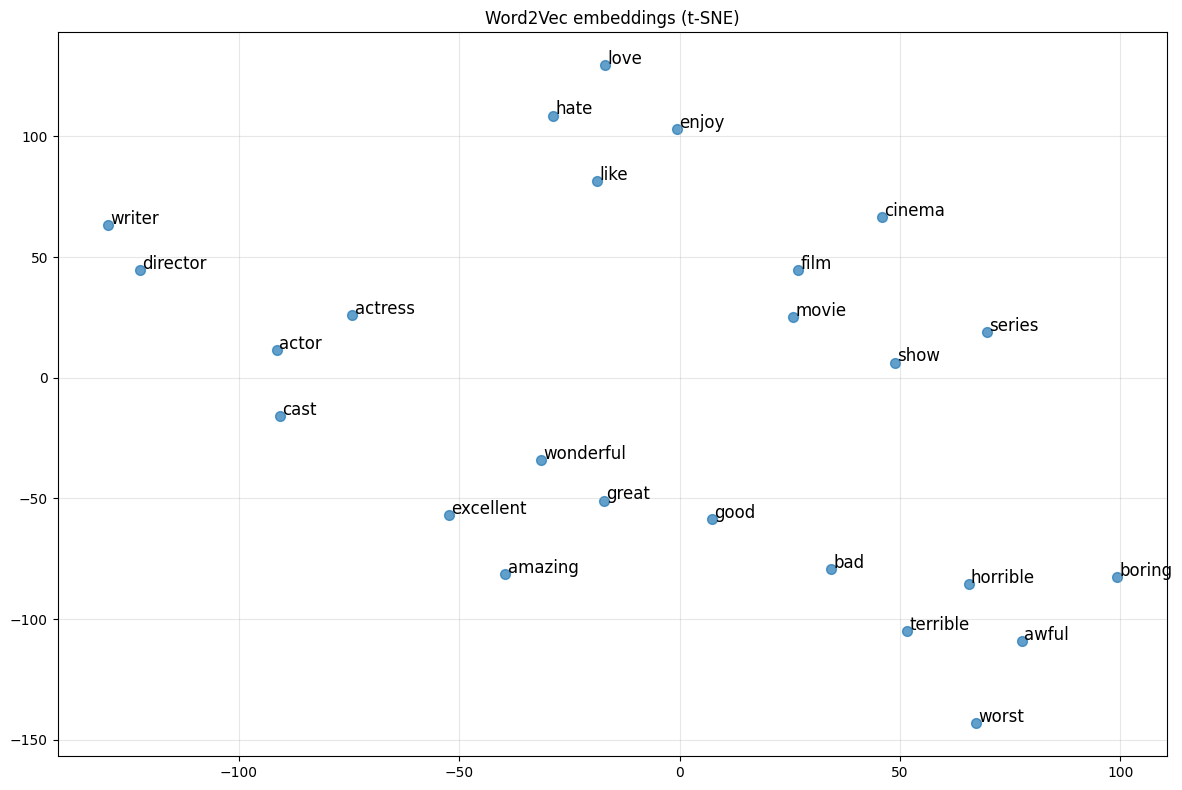

In [16]:
words_to_plot = [
    'movie', 'film', 'cinema', 'show', 'series',
    'good', 'great', 'excellent', 'amazing', 'wonderful',
    'bad', 'terrible', 'awful', 'horrible', 'worst',
    'actor', 'actress', 'director', 'writer', 'cast',
    'love', 'hate', 'like', 'enjoy', 'boring',
]

vectors = np.array([w2v_model.wv[w] for w in words_to_plot])

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=8,
)
coords = tsne.fit_transform(vectors)

plt.figure(figsize=(12, 8))
plt.scatter(coords[:, 0], coords[:, 1], s=50, alpha=0.7)
for i, word in enumerate(words_to_plot):
    plt.annotate(word, (coords[i, 0] + 0.5, coords[i, 1] + 0.5), fontsize=12)
plt.title('Word2Vec embeddings (t-SNE)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Sentiment Analysis: сравнение подходов

У нас уже есть TF-IDF baseline (acc ~0.88). Теперь сравним с подходом на Word2Vec.

**Стратегия усреднения (mean pooling)**: берём Word2Vec-вектора *всех* слов текста и усредняем — получаем один вектор фиксированной размерности. Если Word2Vec обучен с `vector_size=100`, то каждый текст превращается в вектор длины 100 (вместо 20000 у TF-IDF).

**За счёт чего выигрыш в размерности**: Word2Vec «сжимает» семантику в плотное 100-мерное пространство. Похожие по смыслу слова (good/great/excellent) дают близкие вектора, в отличие от TF-IDF, где это три независимых координаты.

**Потери при усреднении**:
- Теряется порядок слов — «not good» и «good not» дадут одинаковый вектор
- Теряется информация о значимости каждого слова — редкое «masterpiece» весит столько же, сколько частое «the»
- Поэтому TF-IDF + LogReg часто выигрывает у Word2Vec + LogReg — TF-IDF хранит точную информацию о наличии каждого слова

**Зачем тогда MLP**: нейросеть с нелинейными активациями может извлечь из 100 плотных Word2Vec-признаков паттерны, недоступные линейной модели (LogReg).

In [17]:
def embed_text(tokens, model):
    """Усредняем Word2Vec-векторы всех известных слов в тексте."""
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if len(vecs) == 0:
        return np.zeros(model.wv.vector_size)
    return np.mean(vecs, axis=0)


X_train_w2v = np.array([embed_text(t, w2v_model) for t in train_tokens])
X_test_w2v = np.array([embed_text(t, w2v_model) for t in test_tokens])

print(f"W2V-фичи: {X_train_w2v.shape} (сравните с TF-IDF: {X_train_tfidf.shape})")

W2V-фичи: (25000, 100) (сравните с TF-IDF: (25000, 20000))


### Word2Vec + логистическая регрессия

In [18]:
clf_w2v = LogisticRegression(max_iter=1000)
clf_w2v.fit(X_train_w2v, y_train)

w2v_lr_train_acc = accuracy_score(y_train, clf_w2v.predict(X_train_w2v))
w2v_lr_test_acc = accuracy_score(y_test, clf_w2v.predict(X_test_w2v))

print(f"Word2Vec + LogReg")
print(f"  Train accuracy: {w2v_lr_train_acc:.3f}")
print(f"  Test accuracy:  {w2v_lr_test_acc:.3f}")

Word2Vec + LogReg
  Train accuracy: 0.854
  Test accuracy:  0.842


Word2Vec + LogReg уступает TF-IDF + LogReg. Это ожидаемо:

- **TF-IDF** сохраняет информацию о каждом слове отдельно — если в отзыве встретилось «terrible», это напрямую влияет на соответствующий признак
- **Word2Vec + mean** «смешивает» все слова в одну точку в 100-мерном пространстве — логистической регрессии сложно разделить это линейно

Зато размерность в 200 раз меньше (100 vs 20000), и в этих 100 признаках закодирована *семантика*.

Попробуем нейросеть (MLP) — она умеет моделировать нелинейные зависимости и может вытянуть больше из плотного представления.

### Word2Vec + нейросеть (MLP)

In [19]:
X_train_t = torch.tensor(X_train_w2v, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test_w2v, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
test_ds = torch.utils.data.TensorDataset(X_test_t, y_test_t)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=256)

Архитектура `SentimentMLP`:

- **Вход**: вектор размерности 100 (усреднённый Word2Vec)
- **Слой 1**: `Linear(100 → 128)` + `ReLU` + `Dropout(0.3)` — проекция в более широкое пространство, нелинейная активация и регуляризация (случайно зануляем 30% нейронов при обучении, чтобы сеть не переобучалась)
- **Слой 2**: `Linear(128 → 64)` + `ReLU` + `Dropout(0.3)` — сужаем представление
- **Выход**: `Linear(64 → 2)` — два логита для двух классов (pos/neg)

Обучение:
- **Adam(lr=1e-3)** — адаптивный оптимизатор, подбирает learning rate для каждого параметра отдельно. Работает хорошо «из коробки» на большинстве задач.
- **CrossEntropyLoss** — стандартный лосс для классификации. Внутри делает softmax + negative log-likelihood. Чем увереннее модель в правильном классе, тем меньше потеря.

In [20]:
class SentimentMLP(nn.Module):
    def __init__(self, input_dim=100, hidden_dim=128, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, x):
        return self.net(x)


mlp_model = SentimentMLP().to(device)
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

print(f"Параметров: {sum(p.numel() for p in mlp_model.parameters()):,}")

Параметров: 21,314


Epoch  1 | Loss: 0.6201 | Test acc: 0.758
Epoch  5 | Loss: 0.3805 | Test acc: 0.823
Epoch 10 | Loss: 0.3478 | Test acc: 0.843
Epoch 15 | Loss: 0.3421 | Test acc: 0.838
Epoch 20 | Loss: 0.3315 | Test acc: 0.849


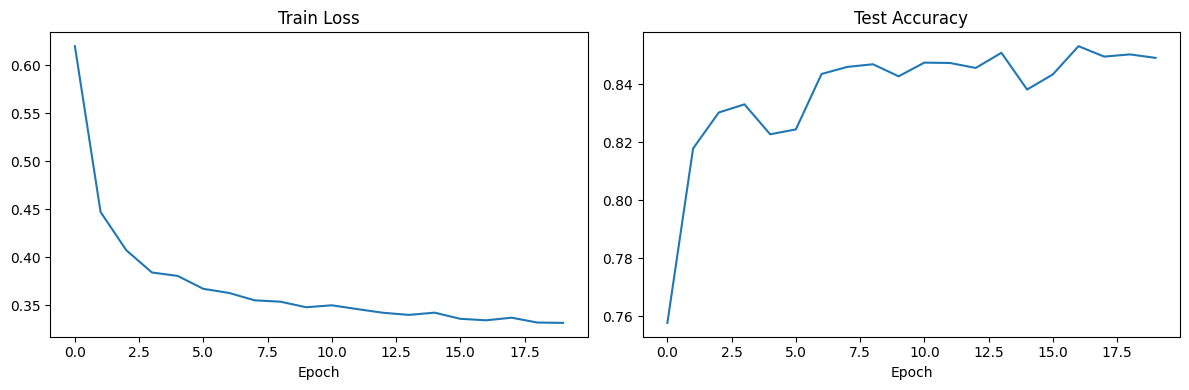

In [21]:
n_epochs = 20
train_losses, test_accs = [], []

for epoch in range(n_epochs):
    mlp_model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(mlp_model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    mlp_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = mlp_model(X_batch).argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)
    test_accs.append(correct / total)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d} | Loss: {train_losses[-1]:.4f} | Test acc: {test_accs[-1]:.3f}")

w2v_mlp_test_acc = max(test_accs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses); ax1.set_title('Train Loss'); ax1.set_xlabel('Epoch')
ax2.plot(test_accs); ax2.set_title('Test Accuracy'); ax2.set_xlabel('Epoch')
plt.tight_layout()
plt.show()

### Сводная таблица

In [22]:
print(f"{'Метод':<25} {'Размерность':<15} {'Test Accuracy'}")
print("-" * 55)
print(f"{'TF-IDF + LogReg':<25} {'20,000':<15} {tfidf_test_acc:.3f}")
print(f"{'Word2Vec + LogReg':<25} {'100':<15} {w2v_lr_test_acc:.3f}")
print(f"{'Word2Vec + MLP':<25} {'100':<15} {w2v_mlp_test_acc:.3f}")
print()
print("TF-IDF пока впереди — но Word2Vec всего 100 признаков!")
print("На следующем занятии увидим, как BERT решает эту задачу.")

Метод                     Размерность     Test Accuracy
-------------------------------------------------------
TF-IDF + LogReg           20,000          0.880
Word2Vec + LogReg         100             0.842
Word2Vec + MLP            100             0.853

TF-IDF пока впереди — но Word2Vec всего 100 признаков!
На следующем занятии увидим, как BERT решает эту задачу.


---
## 6. RNN: генерация имён

**Зачем RNN?** Все предыдущие модели (BoW, TF-IDF, Word2Vec + усреднение) теряют информацию о **порядке** слов/символов. «Фильм хороший, но конец плохой» и «Фильм плохой, но конец хороший» — для BoW это одно и то же. RNN решает эту проблему.

**RNN (Recurrent Neural Network)** обрабатывает вход **последовательно**: на каждом шаге получает элемент и обновляет скрытое состояние (hidden state), которое является «памятью» сети. Формально: $h_t = f(W_h h_{t-1} + W_x x_t + b)$.

**Проблема ванильных RNN**: при обратном распространении через длинные последовательности градиенты **затухают** (vanishing gradients) или **взрываются** (exploding gradients). Из-за этого стандартная RNN не способна запоминать зависимости на большом расстоянии.

**LSTM (Long Short-Term Memory)** решает эту проблему с помощью трёх вентилей (gates):
- **Forget gate** — решает, какую часть старой информации забыть
- **Input gate** — решает, какую новую информацию записать
- **Output gate** — решает, что из памяти выдать наружу

Благодаря вентилям градиенты могут «протекать» через ячейку памяти без затухания, и модель учится на длинных зависимостях.

---

Обучим посимвольную языковую модель (LSTM) на корпусе английских имён.
Задача: по последовательности символов предсказать следующий символ. После обучения модель сможет **генерировать** правдоподобные имена.

### Подготовка данных

In [23]:
from nltk.corpus import names as names_corpus

all_names = names_corpus.words()
print(f"Всего имён: {len(all_names)}")
print(f"Примеры: {all_names[:10]}")

PAD = ' '
chars = sorted(set(''.join(all_names)))
chars = [PAD] + chars
num_tokens = len(chars)
token_to_id = {c: i for i, c in enumerate(chars)}

print(f"\nАлфавит ({num_tokens} символов): {''.join(chars)}")

Всего имён: 7944
Примеры: ['Abagael', 'Abagail', 'Abbe', 'Abbey', 'Abbi', 'Abbie', 'Abby', 'Abigael', 'Abigail', 'Abigale']

Алфавит (56 символов):   '-ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


In [24]:
MAX_LEN = 16

def names_to_matrix(names_list, max_len=MAX_LEN):
    """Конвертируем список имён в матрицу индексов с паддингом."""
    matrix = np.zeros((len(names_list), max_len), dtype=np.int64)
    for i, name in enumerate(names_list):
        ids = [token_to_id[c] for c in name[:max_len]]
        matrix[i, :len(ids)] = ids
    return matrix

### Модель: CharLSTM

Архитектура: `Embedding → LSTM → Linear`.

Разберём каждый слой:
- **`nn.Embedding(num_tokens, emb_size=16)`** — превращает дискретный индекс символа (число от 0 до 55) в плотный вектор размерности 16. Это обучаемая таблица: каждому символу соответствует свой вектор, который модель подбирает в процессе обучения.
- **`nn.LSTM(emb_size, hidden_size=64, batch_first=True)`** — рекуррентный слой. `hidden_size=64` означает, что «память» сети — вектор из 64 чисел. На каждом шаге LSTM получает эмбеддинг текущего символа и скрытое состояние с предыдущего шага, и выдаёт новое скрытое состояние.
- **`nn.Linear(hidden_size, num_tokens)`** — линейный слой, который преобразует скрытое состояние в логиты (ненормализованные вероятности) для каждого символа алфавита.

На каждом шаге модель получает символ и предсказывает распределение вероятностей следующего символа.

In [29]:
class CharLSTM(nn.Module):
    def __init__(self, num_tokens, emb_size=16, hidden_size=64):
        super().__init__()
        self.emb = nn.Embedding(num_tokens, emb_size)
        self.rnn = nn.LSTM(emb_size, hidden_size, batch_first=True)
        self.head = nn.Linear(hidden_size, num_tokens)

    def forward(self, x):
        h_seq, _ = self.rnn(self.emb(x))
        return self.head(h_seq)


rnn_model = CharLSTM(num_tokens).to(device)
rnn_opt = torch.optim.Adam(rnn_model.parameters(), lr=1e-3)
rnn_criterion = nn.CrossEntropyLoss()

print(f"Параметров: {sum(p.numel() for p in rnn_model.parameters()):,}")

Параметров: 25,528


### Обучение

Loss: кросс-энтропия между предсказанным и реальным следующим символом.

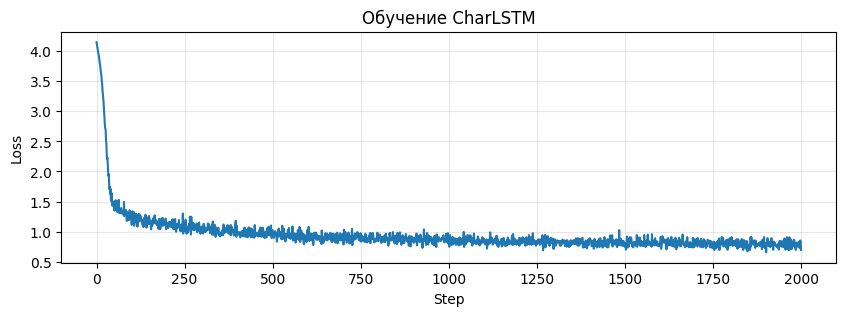

In [30]:
from random import sample as random_sample

history = []

for step in range(2000):
    batch = names_to_matrix(random_sample(all_names, 32))
    batch = torch.tensor(batch, dtype=torch.long, device=device)

    logits = rnn_model(batch)
    loss = rnn_criterion(
        logits[:, :-1].reshape(-1, num_tokens),
        batch[:, 1:].reshape(-1),
    )

    rnn_opt.zero_grad()
    loss.backward()
    rnn_opt.step()
    history.append(loss.item())

plt.figure(figsize=(10, 3))
plt.plot(history)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Обучение CharLSTM')
plt.grid(alpha=0.3)
plt.show()

### Генерация

Обученная модель на каждом шаге выдаёт **логиты** — ненормализованные оценки для каждого символа. Перед тем как сэмплировать следующий символ, мы пропускаем логиты через softmax. Именно на этом этапе вступает в игру **temperature**.

**Как работает temperature**: перед softmax делим логиты на T:

$$p_i = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}$$

- При **T → 0** — распределение «заостряется»: модель почти всегда выбирает символ с наибольшим логитом. Результат предсказуемый, но однообразный.
- При **T = 1** — распределение совпадает с тем, что модель реально выучила.
- При **T → ∞** — распределение становится равномерным: модель выбирает символы случайно. Результат разнообразный, но часто бессмысленный.

На практике:
- **Низкая** (0.3) → консервативные, предсказуемые имена
- **Средняя** (0.7) → баланс между разнообразием и качеством
- **Высокая** (1.5) → необычные, часто бессмысленные комбинации

In [27]:
def generate_name(model, seed=' ', max_len=MAX_LEN, temperature=1.0):
    """Генерируем имя посимвольно."""
    model.eval()
    ids = [token_to_id[c] for c in seed]
    x = torch.tensor([ids], dtype=torch.long, device=device)

    with torch.no_grad():
        for _ in range(max_len - len(seed)):
            logits = model(x)
            probs = F.softmax(logits[0, -1] / temperature, dim=-1)
            next_id = torch.multinomial(probs, 1).item()
            x = torch.cat([x, torch.tensor([[next_id]], device=device)], dim=1)

    return ''.join(chars[i] for i in x[0].cpu().tolist()).strip()


for temp, label in [(0.3, 'Низкая'), (0.7, 'Средняя'), (1.5, 'Высокая')]:
    print(f"\ntemperature={temp} ({label}):")
    for _ in range(5):
        print(f"  {generate_name(rnn_model, temperature=temp)}")


temperature=0.3 (Низкая):
  ellina
  alina
  erna
  eline
  aris

temperature=0.7 (Средняя):
  ibby
  euransta
  ana
  olella
  andy

temperature=1.5 (Высокая):
  Flbe
  an n
  orceeis
  Hagm
  wiy


In [28]:
print("С затравкой 'A':")
for _ in range(5):
    print(f"  {generate_name(rnn_model, seed='A', temperature=0.5)}")

print("\nС затравкой 'M':")
for _ in range(5):
    print(f"  {generate_name(rnn_model, seed='M', temperature=0.5)}")

С затравкой 'A':
  Allis
  Andie
  Annie
  Annelia
  Andris

С затравкой 'M':
  Marga
  Maris
  Morile
  Marrie
  Maris
